In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Landscapes

For a deep learning problem we first define a loss function, and once we
have it, an optimization algorithm drives it down. In optimization the loss
is called the *objective function*; by convention we minimize, and if we
ever need to maximize something, flipping the sign of the objective
suffices. One more convention: the optimization literature writes the thing
being adjusted as a single vector $\mathbf{x}$, so for the next few sections
$\mathbf{x}$ bundles up all the parameters that earlier chapters wrote as
$(\mathbf{w}, b)$ — same object, shorter name. None of this is difficult to state. What is difficult is the
surface being minimized: the graph of a deep network's loss over a
parameter space with millions of dimensions, and the shape of that surface
decides which algorithms work. This section surveys the terrain before the
chapter builds the machinery: what minimizing the objective does and does
not accomplish, the places where gradients die, and the two properties of
the surface — curvature and noise — that set the pace of every method that
follows.

One idea organizes the whole chapter. An optimizer is three decisions.
First, a *descent direction*: which way counts as "down" depends on which
norm measures the size of a step — the gradient is the answer under the
Euclidean norm, not the only answer, and changing the norm changes the
algorithm, a thread that pays off in that section. Second, a *step
size over time*: how far to trust the local slope, and how that trust
should shrink or grow over a training run, the subject of
that section. Third, a *way of living with noise*: at any
interesting scale the gradient is an estimate computed on a minibatch,
and the batch size, together with averaging over time, decides how noisy
an estimate we act on
(that section, that section). Each method in
this chapter, from gradient descent to Muon, is a particular way of making
these three decisions.

## The Goal of Optimization

Optimization supplies deep learning with a means, but the two have
different ends. Optimization cares about the objective it was handed;
learning cares about performance on data the model has never seen. As
discussed in that section, training error and
generalization error generally differ, and driving the first toward zero
can even hurt the second. In the vocabulary of
that section, the *empirical risk* is the
average loss over the training set, while the *risk* is the expected loss
over the whole population. The optimizer only ever sees the former.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
from jax import numpy as jnp
import numpy as np

To make the gap concrete we define two functions: a smooth risk function
`f`, and an empirical risk function `g` that wobbles around it, the way an
average over finitely many training examples wobbles around an
expectation.

In [2]:
def f(x):
    return x * d2l.cos(np.pi * x)

def g(x):
    return f(x) + 0.2 * d2l.cos(5 * np.pi * x)

The minimum of the empirical risk need not sit at the minimum of the risk,
and here it does not:

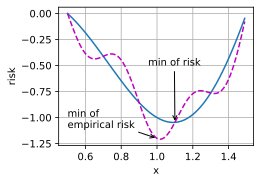

In [3]:
def annotate(text, xy, xytext):
    d2l.plt.gca().annotate(text, xy=xy, xytext=xytext,
                           arrowprops=dict(arrowstyle='->'))

x = d2l.arange(0.5, 1.5, 0.01)
d2l.set_figsize((4.5, 2.5))
d2l.plot(x, [f(x), g(x)], 'x', 'risk')
annotate('min of\nempirical risk', (1.0, -1.2), (0.5, -1.1))
annotate('min of risk', (1.1, -1.05), (0.95, -0.5))

No optimizer, however good, can close this gap: it is a property of the
data, not of the algorithm, and closing it is the business of the
regularization and model-selection tools met earlier in the book. For the
rest of the chapter we therefore set generalization aside and take the
objective at face value. Even so restricted, the problem is hard. Deep
learning objectives admit no analytical solution of the kind we found for
linear regression in that section, so every algorithm
in this chapter is iterative — and the surface it iterates over is nothing
like a convex bowl.

## Where Gradients Vanish

An iterative method needs a signal to follow, and the gradient is that
signal. The classical hazards of nonconvex optimization are the places
where the signal gives out: local minima, saddle points, and flat regions
of saturated activations. We look at each in turn.

### Local Minima

For an objective function $f(x)$, if the value of $f$ at $x$ is smaller
than at any nearby point, then $x$ is a *local minimum*. If it is smallest
over the entire domain, $x$ is the *global minimum*. For example, the
function

$$f(x) = x \cdot \textrm{cos}(\pi x) \textrm{ for } -1.0 \leq x \leq 2.0$$

has a local minimum that is not global:

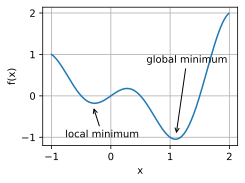

In [4]:
x = d2l.arange(-1.0, 2.0, 0.01)
d2l.plot(x, [f(x), ], 'x', 'f(x)')
annotate('local minimum', (-0.3, -0.25), (-0.77, -1.0))
annotate('global minimum', (1.1, -0.95), (0.6, 0.8))

Deep learning objectives have many local minima, and an iterate that lands
near one sees its gradient approach zero: from the signal alone, a local
minimum is indistinguishable from the global one. Noise can dislodge the
parameters, at least from a shallow basin — one reason, as we will see
below, that the noise in minibatch gradients is not purely a nuisance.

### Saddle Points

Besides local minima, *saddle points* make gradients vanish: locations
where every gradient component is zero but which are neither a minimum nor
a maximum of the function. Consider $f(x) = x^3$. Its first and second
derivatives both vanish at $x=0$, and optimization can stall there even
though it is no minimum at all:

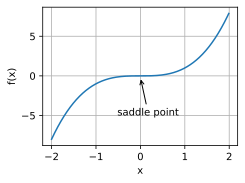

In [5]:
x = d2l.arange(-2.0, 2.0, 0.01)
d2l.plot(x, [x**3], 'x', 'f(x)')
annotate('saddle point', (0, -0.2), (-0.52, -5.0))

Saddle points in higher dimensions are more insidious. Consider
$f(x, y) = x^2 - y^2$: its saddle point at $(0, 0)$ is a minimum with
respect to $x$ and a maximum with respect to $y$, and the surface looks
like the saddle that gives the phenomenon its name:

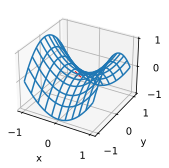

In [6]:
x, y = d2l.meshgrid(
    d2l.linspace(-1.0, 1.0, 101), d2l.linspace(-1.0, 1.0, 101))
z = x**2 - y**2

ax = d2l.plt.figure().add_subplot(111, projection='3d')
ax.plot_wireframe(x, y, z, **{'rstride': 10, 'cstride': 10})
ax.plot([0], [0], [0], 'rx')
ticks = [-1, 0, 1]
d2l.plt.xticks(ticks)
d2l.plt.yticks(ticks)
ax.set_zticks(ticks)
d2l.plt.xlabel('x')
d2l.plt.ylabel('y');

Why saddle points dominate in high dimension is a counting argument.
Suppose the input of a function is a $k$-dimensional vector and its output
a scalar, so its Hessian matrix has $k$ eigenvalues. At a point where the
gradient is zero:

* if all $k$ eigenvalues are positive, we have a local minimum;
* if all are negative, a local maximum;
* if some are positive and some negative, a saddle point.

For a zero-gradient point of a high-dimensional function to be a local
minimum, *every one* of thousands or millions of eigenvalues must be
positive; if signs were even roughly balanced coin flips, nearly every
critical point would be a saddle. Convex functions — those whose Hessian
eigenvalues are nowhere negative — have neither saddle points nor spurious
minima, which is one reason classical optimization theory is built on
them. Deep learning objectives are not convex, but the theory has not
therefore become useless; we return to what it still offers at the end of
this section.

### Vanishing Gradients

The most insidious way to starve the gradient signal involves no critical
point at all. This is old news by now — that section
diagnosed vanishing and exploding gradients through depth and prescribed
initialization, and that section traced the same disease through time
— but it is worth seeing in its purest one-dimensional form. Recall the
activation functions of
that section and suppose we want to minimize
$f(x) = \tanh(x)$ starting from $x = 4$. The derivative is
$f'(x) = 1 - \tanh^2(x)$, so $f'(4) = 0.0013$: the surface is simply very
flat where we happen to stand, and gradient descent barely moves for a
long time before making progress.

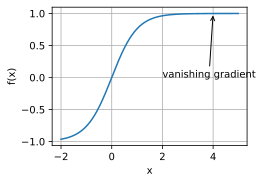

In [7]:
x = d2l.arange(-2.0, 5.0, 0.01)
d2l.plot(x, [d2l.tanh(x)], 'x', 'f(x)')
annotate('vanishing gradient', (4, 1), (2, 0.0))

Vanishing gradients made deep networks genuinely hard to train before the
ReLU activation and careful initialization; those fixes belong to model
design (that section) rather than to the
optimizer. The hazards of this section, then, are real, but two facts
soften them. Deep learning does not need *the* global minimum — a good
approximate local one serves — and, as the next section shows, what
actually limits training speed day to day is usually something else.

## Curvature and Noise

Zero-gradient traps are the textbook picture of why nonconvex
optimization is hard. In daily practice they are rarely what hurts.
Training is slow, or unstable, for two humbler reasons: the gradient is a
poor guide when curvature differs across directions, and we never see the
exact gradient anyway. These two — ill-conditioning and noise — are the
recurring villains of this chapter, and most of its methods exist to fight
one or the other.

### An Ill-Conditioned Valley

Take the simplest curved objective, a quadratic valley

$$f(\mathbf{x}) = 0.1 x_1^2 + 2 x_2^2,$$

which curves gently along $x_1$ (second derivative $0.2$) and steeply
along $x_2$ (second derivative $4$). Gradient descent updates both
coordinates with the same learning rate $\eta$, and each step multiplies
$x_1$ by $1 - 0.2\,\eta$ and $x_2$ by $1 - 4\eta$. The steep direction
sets a ceiling: for $x_2$ to shrink rather than explode we need
$|1 - 4\eta| < 1$, that is $\eta < 0.5$. The flat direction sets the pace:
for any stable $\eta$, each step keeps more than $90\%$ of $x_1$. To watch
the squeeze we borrow two helpers built in that section —
`d2l.train_2d` iterates an update rule from a fixed starting point, and
`d2l.show_trace_2d` draws the resulting trace over the objective's
contours — and run 30 steps at $\eta = 0.45$, just under the ceiling:

epoch 30, x1: -0.295265, x2: -0.002476


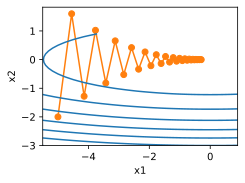

In [8]:
def f_valley(x1, x2):  # Second derivatives 0.2 and 4
    return 0.1 * x1 ** 2 + 2 * x2 ** 2

def gd_valley(x1, x2, s1, s2):
    eta = 0.45  # Just under the stability ceiling of 0.5
    return (x1 - eta * 0.2 * x1, x2 - eta * 4 * x2, 0, 0)

d2l.show_trace_2d(f_valley, d2l.train_2d(gd_valley, steps=30))

The trace is the signature of ill-conditioning: zig-zag *across* the
valley, crawl *along* it. The steep coordinate overshoots the valley floor
on every step, its sign flipping each iteration, while the flat coordinate
sheds only nine percent of its remaining distance per step — at that rate,
every factor of ten along $x_1$ costs about 24 steps. The number that controls this
squeeze is the ratio of the largest to the smallest curvature, the
*condition number*

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}},$$

here $4/0.2 = 20$. In general the steep curvature caps the learning rate
at $2/\lambda_{\max}$, the flat curvature then contracts by only
$1 - 2/\kappa$ per step, and the iteration count grows *linearly* with
$\kappa$ — the arithmetic is worked out in
that section. For deep networks $\kappa$ is not
$20$; measured values run to the thousands and beyond, and this valley,
with the squeeze turned up, is the right mental model for why plain
gradient descent crawls. Much of the
chapter is aimed at exactly this picture: momentum cuts the effective cost
from $\kappa$ to $\sqrt{\kappa}$ (that section), adaptive
methods rescale each coordinate by its own history (that section),
and Muon rescales whole matrices at once (that section).

### The Edge of Stability

The valley analysis treats curvature as a fixed property of the surface,
and the classical advice follows from it: measure the sharpness
$\lambda_{\max}$, then choose $\eta < 2/\lambda_{\max}$. On real networks
the causality runs backwards. Train a network with full-batch gradient
descent and the sharpness *rises* — "progressive sharpening" — until it
reaches roughly $2/\eta$, and then hovers there, with the loss still
falling, non-monotonically, in the very regime the quadratic analysis
forbids [@Cohen.Kaur.Li.ea.2021]. The stability ceiling behaves less
like a fence the optimizer must stay behind and more like an attractor it
equilibrates onto: you pick $\eta$, and the network adapts its curvature
to your choice. Training does not live in the tidy descent regime that
most of this chapter's stated results (and the appendix's proofs) analyze;
the results remain the right guide to the mechanisms, but this is a gap
worth knowing about, and it is one reason the learning-rate schedules of
that section — warmup especially — matter as much as they do.
The phenomenon is easy to check on a 25-parameter network, and
that section does exactly that.

### Noisy Gradients

The second villain is that the gradient we act on is an estimate. The loss
is an average over the training set, so computing its exact gradient costs
a full pass over the data; every practical method instead uses a minibatch
of $b$ examples. The estimate is unbiased, and its variance falls like
$1/b$ — that section measures this on a real network, nearly three
orders of magnitude of batch size falling neatly on the $1/b$ line. Noise
changes the character of the iteration: with a constant learning rate the
parameters do not converge but rattle around the optimum in a *noise
ball* whose squared radius scales with $\eta$, which is the fundamental
reason learning rates must decay (that section, that section).
Batch size becomes a second dial next to the learning rate — one with
hardware consequences (that section) and, at scale, a
measurable point of diminishing returns (that section) — and
averaging over time, momentum's second job, quiets noise that batching
alone leaves behind (that section). Nor is noise purely a tax:
it helps bounce the iterate out of the shallow local minima and saddle
points of the previous section — though gradient descent from a random
start escapes strict saddles even without noise, and a deep basin is
expensive to leave, noise or not. Living with noise — spending it,
canceling it, budgeting for it — is the third of the chapter's three
decisions.

## What Convexity Still Buys

Every surface in this section was nonconvex, deliberately so. Yet the
vocabulary we used to describe them — condition number, convergence rate,
noise ball — comes from *convex* analysis, where each of these is a
theorem rather than a cartoon. That is the first thing convexity still
buys: a language, and clean baselines. A convex function has no bad local
minima and no saddle points to hide in, so any weakness an optimizer shows
on a convex problem is intrinsic to the optimizer. If a method misbehaves
on a quadratic, it has no business near a transformer, and throughout this
chapter new methods meet quadratics first.

The second purchase is local. Near a good minimum, a smooth loss is
approximately a quadratic bowl — the bottom of the surface looks locally
convex even when the whole is anything but. This is why the valley
analysis above predicts the late-training behavior of real networks, and
it underwrites practical tricks: averaging iterates near the bottom of the
bowl, as in stochastic weight averaging
[@Izmailov.Podoprikhin.Garipov.ea.2018], is a convex-analysis idea
that transfers to deep networks essentially intact
(that section).

The limits are just as instructive. A deep network's loss cannot be convex
globally: permuting the hidden units of a layer leaves the function
computed unchanged, so every minimum comes with a combinatorial family of
separated copies of itself — the first exercise below makes this precise —
while a convex function's minima form a single connected set. Convexity
for deep learning is therefore a local approximation and a source of
tools, never a global fact. The full treatment — convex sets and
functions, Jensen's inequality, why local minima of convex functions are
global, duality, projections — lives in that section of the
mathematical appendix, whose optimization chapter
(that section) carries the proofs this chapter owes.

## Summary

Optimization and learning share a loss function but not a goal: the
optimizer minimizes empirical risk, while learning wants low risk, and no
optimizer can close that gap by itself. On the training objective, the
classical hazards are the places where gradients vanish — local minima,
saddle points (overwhelmingly more common in high dimension), and
saturated activations. The hazards that dominate practice are different:
curvature, summarized by the condition number $\kappa$, which forces a
single learning rate to serve directions of very different steepness; and
noise, since minibatch gradients are estimates whose variance we choose
via the batch size. Real training adds a twist to the classical stability
story — sharpness rises until it sits at the edge that the step size
tolerates. Convex analysis survives all this as a source of vocabulary,
baselines, and local approximations. The rest of the chapter builds the
machinery: a descent direction, a step size over time, and a way of
living with noise.

## Exercises

1. Consider a simple MLP with a single hidden layer of, say, $d$
   dimensions in the hidden layer and a single output. Show that for any
   local minimum there are at least $d!$ equivalent solutions that behave
   identically.
1. Assume that we have a symmetric random matrix $\mathbf{M}$ where the
   entries $M_{ij} = M_{ji}$ are each drawn from some probability
   distribution $p_{ij}$. Furthermore assume that $p_{ij}(x) = p_{ij}(-x)$,
   i.e., that the distribution is symmetric (see e.g.,
   @Wigner.1958 for details).
    1. Prove that the distribution over eigenvalues is also symmetric.
       That is, for any eigenvector $\mathbf{v}$ the probability that the
       associated eigenvalue $\lambda$ satisfies
       $P(\lambda > 0) = P(\lambda < 0)$.
    1. Why does the above *not* imply $P(\lambda > 0) = 0.5$?
1. Assume that you want to balance a (real) ball on a (real) saddle.
    1. Why is this hard?
    1. Can you exploit this effect also for optimization algorithms?
1. Consider the valley $f(\mathbf{x}) = 0.1 x_1^2 + 2 x_2^2$ from this
   section.
    1. What is the largest learning rate for which gradient descent still
       converges? Verify your answer with `d2l.train_2d`.
    1. At $\eta = 0.45$, by what factor per step do $|x_1|$ and $|x_2|$
       shrink? Roughly how many steps does it take to reduce $|x_1|$ by a
       factor of $100$? Check your prediction numerically.
    1. For $f(\mathbf{x}) = \frac{\lambda_{\min}}{2} x_1^2 +
       \frac{\lambda_{\max}}{2} x_2^2$ with the best stable learning rate,
       show that the number of steps needed grows linearly with the
       condition number $\kappa = \lambda_{\max}/\lambda_{\min}$.
    1. Suppose you were allowed to rescale the coordinate
       $\tilde{x}_1 = \alpha x_1$ before optimizing. Which $\alpha$ makes
       the valley perfectly conditioned? Which sections of this chapter
       estimate such rescalings automatically, from gradients alone?
1. What other challenges involved in deep learning optimization can you
   think of?

[Discussions](https://d2l.discourse.group/t/489)